## Bonus - Chemostat with Mixed-Growth-Associated Product Formation (Luedeking-Piret)

### System Equations

The growth rate follows Monod kinetics:
$$\mu = \frac{\mu_m S}{K_s + S}$$

Mass balances in a chemostat (constant volume):
$$\frac{dX}{dt} = \mu X - DX$$
$$\frac{dS}{dt} = D(S_0 - S) - \frac{\mu X}{Y_{x/s}}$$
$$\frac{dP}{dt} = (\alpha \mu + \beta) X - DP$$

The term $(\alpha \mu + \beta)$ is the **Luedeking-Piret model**:
product formation is partly growth-associated ($\alpha \mu$)
and partly non-growth-associated ($\beta$, maintenance).

### Steady State

At steady state, $dX/dt = 0$, therefore $\mu = D$.

Inverting Monod:
$$S = \frac{K_s D}{\mu_m - D}$$

Substrate balance:
$$X = Y_{x/s}(S_0 - S)$$

Product balance ($dP/dt = 0$):
$$P = \frac{(\alpha D + \beta) X}{D}$$

The **productivities** are defined as:
$$\Pi_P = D \cdot P \quad \text{and} \quad \Pi_X = D \cdot X$$

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters (all in g/L)
mu_m  = 0.7    # h^-1
Ks    = 0.02   # g/L  (= 20 mg/L converted)
Yxs   = 0.5    # g cell / g substrate
alpha = 0.1    # g P / g X (growth-associated)
beta  = 0.02   # h^-1 (non-growth-associated production)
S0    = 1      # g/L
P0    = 0      # g/L

# Steady state functions
def S_ss(D):
    """Substrate concentration at SS from mu(S)=D"""
    if D >= mu_m:
        return np.nan
    return Ks * D / (mu_m - D)

def X_ss(D):
    """Cell concentration at SS"""
    S = S_ss(D)
    if np.isnan(S) or S > S0:
        return 0.0
    return Yxs * (S0 - S)

def P_ss(D):
    """Product concentration at SS"""
    if D == 0:
        return np.nan
    X = X_ss(D)
    return (alpha * D + beta) * X / D

def prod_P(D):
    return D * P_ss(D)

def prod_X(D):
    return D * X_ss(D)

In [5]:
D_vals = np.linspace(1e-4, mu_m - 1e-4, 2000)

pP = np.array([prod_P(D) for D in D_vals])
pX = np.array([prod_X(D) for D in D_vals])

idx_P  = np.nanargmax(pP)
idx_X  = np.nanargmax(pX)

D_opt_P = D_vals[idx_P]
D_opt_X = D_vals[idx_X]

print(f"Optimal dilution rate for PRODUCT productivity:")
print(f"  D_opt = {D_opt_P:.4f} h⁻¹")
print(f"  Pi_P  = {pP[idx_P]:.4f} g/L/h")
print()
print(f"Optimal dilution rate for BIOMASS productivity:")
print(f"  D_opt = {D_opt_X:.4f} h⁻¹")
print(f"  Pi_X  = {pX[idx_X]:.4f} g/L/h")

Optimal dilution rate for PRODUCT productivity:
  D_opt = 0.5889 h⁻¹
  Pi_P  = 0.0353 g/L/h

Optimal dilution rate for BIOMASS productivity:
  D_opt = 0.6019 h⁻¹
  Pi_X  = 0.2640 g/L/h


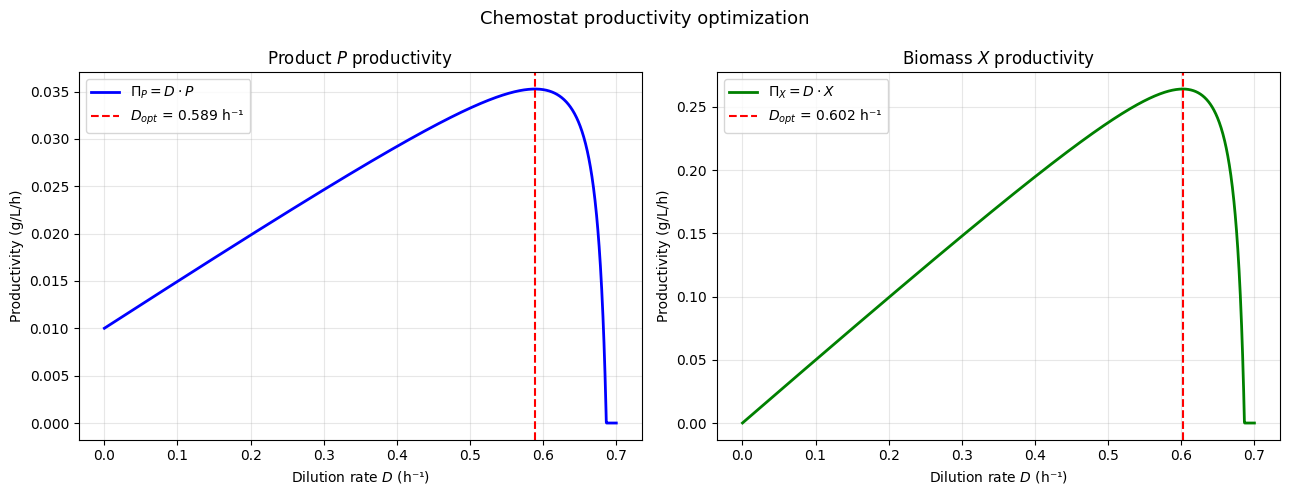

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Product productivity ---
axes[0].plot(D_vals, pP, 'b-', lw=2, label='$\\Pi_P = D \\cdot P$')
axes[0].axvline(D_opt_P, color='r', ls='--', label=f'$D_{{opt}}$ = {D_opt_P:.3f} h⁻¹')
axes[0].set_xlabel('Dilution rate $D$ (h⁻¹)')
axes[0].set_ylabel('Productivity (g/L/h)')
axes[0].set_title('Product $P$ productivity')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Biomass productivity ---
axes[1].plot(D_vals, pX, 'g-', lw=2, label='$\\Pi_X = D \\cdot X$')
axes[1].axvline(D_opt_X, color='r', ls='--', label=f'$D_{{opt}}$ = {D_opt_X:.3f} h⁻¹')
axes[1].set_xlabel('Dilution rate $D$ (h⁻¹)')
axes[1].set_ylabel('Productivity (g/L/h)')
axes[1].set_title('Biomass $X$ productivity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Chemostat productivity optimization', fontsize=13)
plt.tight_layout()
plt.show()

## Interpretation of Results

### Why is D_opt(P) ≠ D_opt(X)?

For **biomass**, the productivity $\Pi_X = D \cdot Y_{x/s}(S_0 - S(D))$
is maximized at an intermediate D: increasing D raises throughput but
lowers $X$ (less residence time → less substrate consumed).

For the **product**, there is an extra $\beta/D$ term in the expression for $P$:
$$P = \left(\alpha + \frac{\beta}{D}\right) X$$

This term favors **low D** values (more residence time → more non-growth-associated
production). The optimum of $\Pi_P$ is therefore shifted toward lower D
compared to $\Pi_X$.

### Washout limit

When $D \to \mu_m$, $S \to S_0$ and $X \to 0$:
cells are diluted faster than they grow → **washout**.
Both productivities drop to zero.

### Conclusion

The optimal D depends on what we want to maximize.
If the added value lies in the **product** (e.g. penicillin),
we operate at a lower D than if we want to maximize **biomass**.